In [1]:
import pandas as pd
import numpy as np
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy.stats import norm

In [2]:
import sys
data_path = '../data/github/'
sys.path.append('../codes/')
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py

In [3]:
data_path = '../data/github/'
vaccination = pd.read_csv(data_path+'vaccination/vaccination_data.csv')

In [4]:
%run ../codes/data_input.py
custom_colors

{'white': '#A6DBD6',
 'black': '#E8E6A3',
 'asian': '#E8B5A4',
 'latino': '#C3A5CE',
 'other': '#E4E4E4',
 'unknown': 'black'}

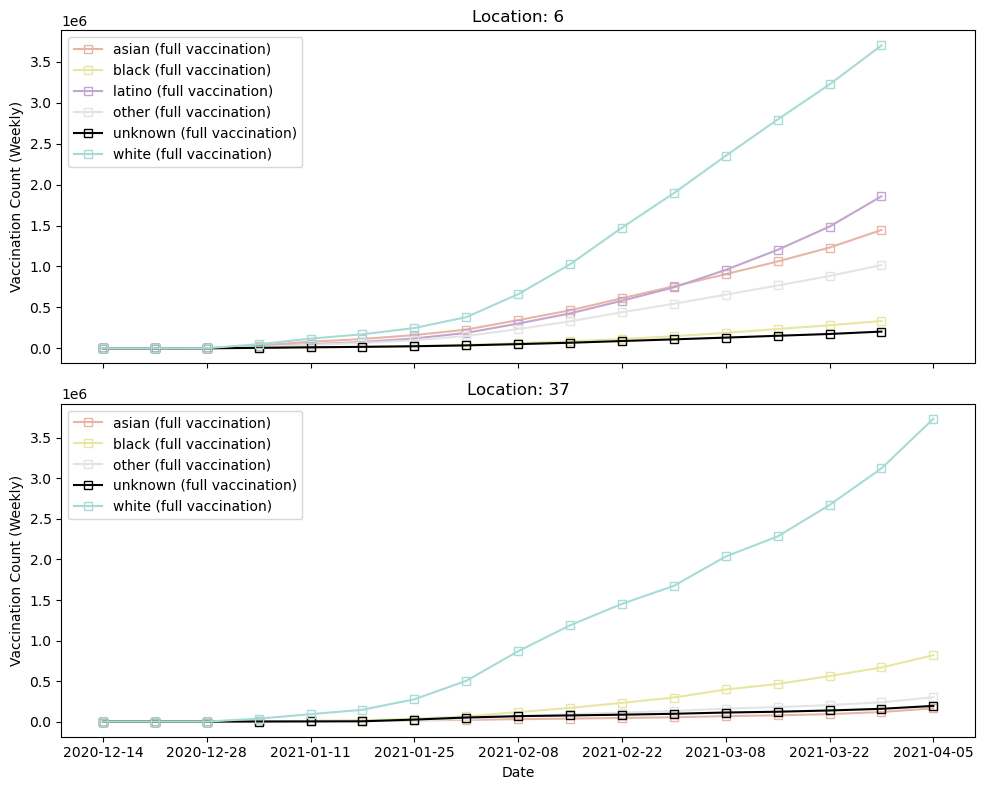

In [5]:
locations = sorted(set(vaccination['location'].unique()).union(vaccination['location'].unique()))
num_locations = len(locations)

fig, axes = plt.subplots(nrows=num_locations, ncols=1, figsize=(10, num_locations * 4), sharex=True)

for idx, location in enumerate(locations):
    ax = axes[idx]
    filtered_data = vaccination[(vaccination['location'] == location) & (vaccination['demographic_category'] == 'race_ethnicity')]
    # Plot 'inc case' on primary y-axis with empty squares
    for race, group in filtered_data.groupby('demographic_value'):
        group.plot(x='date', y='full_vax', ax=ax, label=f"{race} (full vaccination)", marker='s', linestyle='-', color=custom_colors[race], fillstyle='none')

    # Create a secondary y-axis for 'inc death' 
 
    ax.set_title("Location: {}".format(location))
    ax.set_ylabel('Vaccination Count (Weekly)')
    
    # Combine legends from both axes
    lines, labels = ax.get_legend_handles_labels()
    

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [6]:
filtered_data = vaccination[(vaccination['location'] == 6) & (vaccination['demographic_category'] == 'race_ethnicity')]
M_vaccination_06 = np.zeros((len(filtered_data['date'].unique()),len(race_list_06)))
sorted(filtered_data['date'].unique())

['2020-12-19',
 '2020-12-26',
 '2021-01-02',
 '2021-01-09',
 '2021-01-16',
 '2021-01-23',
 '2021-01-30',
 '2021-02-06',
 '2021-02-13',
 '2021-02-20',
 '2021-02-27',
 '2021-03-06',
 '2021-03-13',
 '2021-03-20',
 '2021-03-27',
 '2021-04-03']

In [7]:
for r_idx in range(5):
    race = race_list_06[r_idx]
    print(race)
    vaccination_data = filtered_data[filtered_data['demographic_value']==race]['full_vax'].values
    M_vaccination_06[:,r_idx] = vaccination_data

asian
white
black
latino
other


In [8]:
start_date = '2020-12-19' ## Saturday
num_weeks = M_vaccination_06.shape[0]
# Weekly dates (every Saturday)
dates_weekly = pd.date_range(start=start_date, periods=num_weeks, freq='W-SAT')
# Daily dates range for the entire period, aligning with the weekly start dates
dates_daily = pd.date_range(start=dates_weekly[0] - pd.Timedelta(days=6), end=dates_weekly[-1], freq='D')
# Initialize a daily DataFrame with zeros
daily_df = pd.DataFrame(0.00, index=dates_daily, columns=range(5))
# Distribute weekly values backward
for i, date in enumerate(dates_weekly):
    # Find the start date of the week
    week_start = date - pd.Timedelta(days=6)
    # Assign and distribute weekly values to each day of the corresponding week
    for col in daily_df.columns:
        up = M_vaccination_06[i, col]
        weekly_value = np.array([up]*7)
        daily_df.loc[week_start:date, col] = weekly_value

# Calculate the 7-day rolling average for smoothing, aligning the window to end on the 'start_date'
smoothed_daily_df = daily_df.rolling(window=7, min_periods=1).mean()
df_smoothed_daily_vaccination_06 =  smoothed_daily_df

Text(0, 0.5, 'Vaccination Count (Daily)')

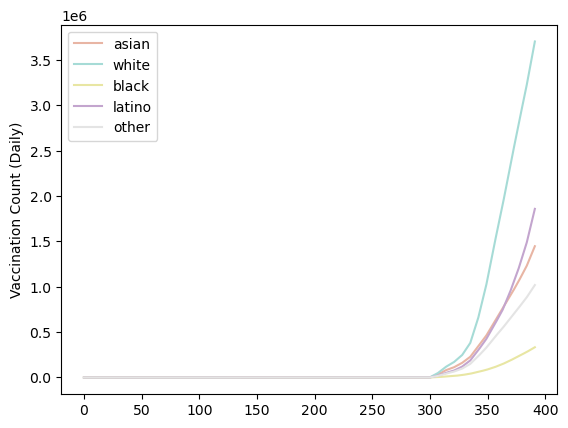

In [9]:
extended_vac_06 = np.zeros(((54+2)*7,5))
extended_vac_06[-df_smoothed_daily_vaccination_06.shape[0]:,:] = df_smoothed_daily_vaccination_06
for r_idx in range(5):
    r = race_list_06[r_idx]
    plt.plot(extended_vac_06[:,r_idx],label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Vaccination Count (Daily)')

#### suscepitble

In [10]:
#actural_inf_06 = (np.loadtxt('serology_infections_06_complete.csv')).reshape(3,5,18)
inf_rates_06 = np.loadtxt('serology_rates_06.csv')

In [11]:
M_susce_pop_06 = np.zeros((13,5))
for r_idx in range(5):
    # M_susce_pop_06[3:,r_idx] = global_N_06[r_idx] - actural_inf_06[1,r_idx,:10]
    M_susce_pop_06[3:,r_idx] = global_N_06[r_idx]*(1 - inf_rates_06[r_idx,:10])
    M_susce_pop_06[:3,r_idx] = global_N_06[r_idx]

In [12]:
from scipy.signal import savgol_filter
def moving_average(data, window_size):
    """ Compute moving average """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [13]:
extended_susce_pop_06 = np.zeros(((54+2)*7,5))
for i in range(3,13):
    extended_susce_pop_06[7*14+(i-3)*30:7*14+(i-3+1)*30,:] = M_susce_pop_06[i]
extended_susce_pop_06[:7*14,:] = M_susce_pop_06[1]

Text(0, 0.5, 'Susceptible Population (Daily)')

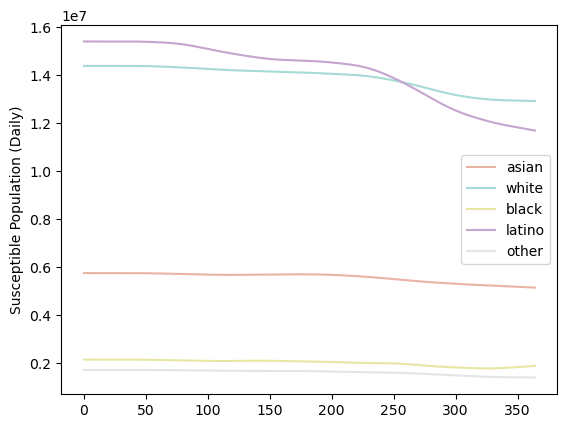

In [14]:
for r_idx in range(5):
    r = race_list_06[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(extended_susce_pop_06[:,r_idx], window_length=70, polyorder=1)
    temp2 = moving_average(temp,28)
    plt.plot(temp2,label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Susceptible Population (Daily)')

In [15]:
M_eta = extended_vac_06/extended_susce_pop_06
M_eta[np.isnan(M_eta)] = 0

Text(0, 0.5, 'Vaccination Rate (Daily)')

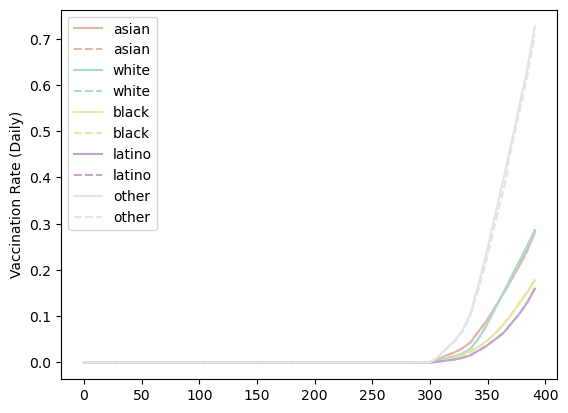

In [18]:
for r_idx in range(5):
    r = race_list_06[r_idx]
    plt.plot(M_eta[:,r_idx],label=r,color=custom_colors[r])
    plt.plot(M_eta_06[:,r_idx],'--',label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Vaccination Rate (Daily)')

In [17]:
# np.savetxt('M_eta_06_v2.csv',M_eta)
# M_eta_06 = np.loadtxt('M_eta_06_v2.csv')

### 037 location

In [19]:
filtered_data = vaccination[(vaccination['location'] == 37) & (vaccination['demographic_category'] == 'race_ethnicity')]
M_vaccination_37 = np.zeros((len(filtered_data['date'].unique()),len(race_list_37)))
sorted(filtered_data['date'].unique())

['2020-12-14',
 '2020-12-21',
 '2020-12-28',
 '2021-01-04',
 '2021-01-11',
 '2021-01-18',
 '2021-01-25',
 '2021-02-01',
 '2021-02-08',
 '2021-02-15',
 '2021-02-22',
 '2021-03-01',
 '2021-03-08',
 '2021-03-15',
 '2021-03-22',
 '2021-03-29',
 '2021-04-05']

In [20]:
for r_idx in range(4):
    race = race_list_37[r_idx]
    print(race)
    vaccination_data = filtered_data[filtered_data['demographic_value']==race]['full_vax'].values
    M_vaccination_37[:,r_idx] = vaccination_data

asian
white
black
other


In [21]:
start_date = '2020-12-13' ## monday
num_weeks = M_vaccination_37.shape[0]
# Weekly dates (every Monday)
dates_weekly = pd.date_range(start=start_date, periods=num_weeks, freq='W-MON')
# Daily dates range for the entire period, aligning with the weekly start dates
dates_daily = pd.date_range(start=dates_weekly[0], end=dates_weekly[-1]+pd.Timedelta(days=6), freq='D')
# Initialize a daily DataFrame with zeros
daily_df = pd.DataFrame(0.00, index=dates_daily, columns=range(4))
# Distribute weekly values backward
for i, date in enumerate(dates_weekly[:]):
    # print(i)
    # Find the start date of the week
    week_end = date + pd.Timedelta(days=6)
    # Assign and distribute weekly values to each day of the corresponding week
    for col in daily_df.columns:
        # low = daily_df.loc[week_start:date, col] = M_weekly[i-1, col] 
        up = M_vaccination_37[i, col] 
        # step = (up - low)/6
        # weekly_value = np.array([low + step * j for j in range(7)])
        weekly_value = np.array([up]*7)
        # print(daily_df)
        # print (weekly_value)
        daily_df.loc[date:week_end,col] =  weekly_value
# Calculate the 7-day rolling average for smoothing, aligning the window to end on the 'start_date'
smoothed_daily_df = daily_df.rolling(window=7, min_periods=1).mean()
df_smoothed_daily_vaccination_37 = smoothed_daily_df

Text(0, 0.5, 'Vaccination Count (Daily)')

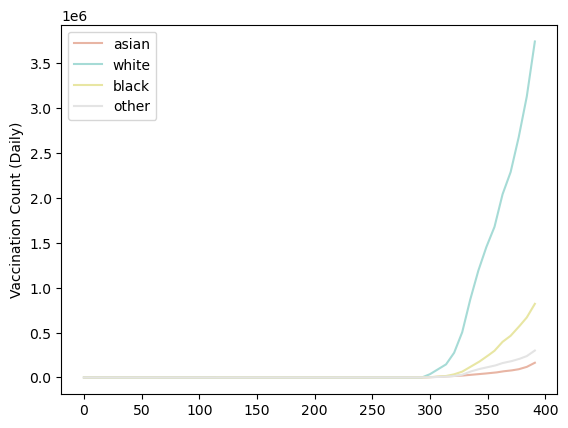

In [22]:
extended_vac_37 = np.zeros(((54+2)*7,4))
extended_vac_37[-df_smoothed_daily_vaccination_37.shape[0]:,:] = df_smoothed_daily_vaccination_37
for r_idx in range(4):
    r = race_list_37[r_idx]
    plt.plot(extended_vac_37[:,r_idx],label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Vaccination Count (Daily)')

In [24]:
# actural_inf_37 = (np.loadtxt('serology_infections_37_complete.csv')).reshape(3,4,18)
inf_rates_37 = np.loadtxt('serology_rates_37.csv')

In [26]:
M_susce_pop_37 = np.zeros((13,4))
for r_idx in range(4):
    M_susce_pop_37[3:,r_idx] = global_N_37[r_idx]*(1 - inf_rates_37[r_idx,:10])
    M_susce_pop_37[:3,r_idx] = global_N_37[r_idx]

In [27]:
extended_susce_pop_37 = np.zeros(((54+2)*7,4))
for i in range(3,13):
    extended_susce_pop_37[7*14+(i-3)*30:7*14+(i-3+1)*30,:] = M_susce_pop_37[i]
extended_susce_pop_37[:7*14,:] = M_susce_pop_37[1]

In [28]:
M_eta = extended_vac_37/extended_susce_pop_37
M_eta[np.isnan(M_eta)] = 0

In [29]:
M_eta.shape

(392, 4)

Text(0, 0.5, 'Susceptible Population (Daily)')

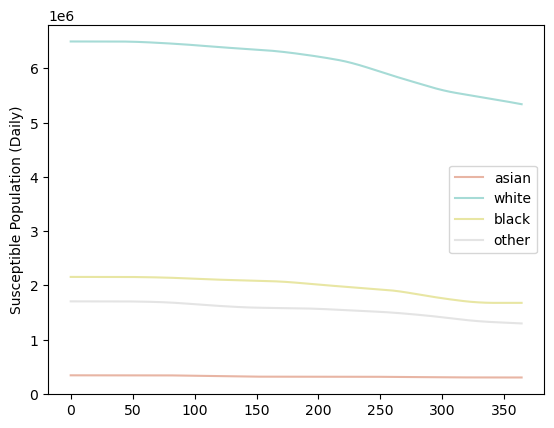

In [30]:
for r_idx in range(4):
    r = race_list_37[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(extended_susce_pop_37[:,r_idx], window_length=70, polyorder=1)
    temp2 = moving_average(temp,28)
    plt.plot(temp2,label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Susceptible Population (Daily)')

Text(0, 0.5, 'Vaccination Rate (Daily)')

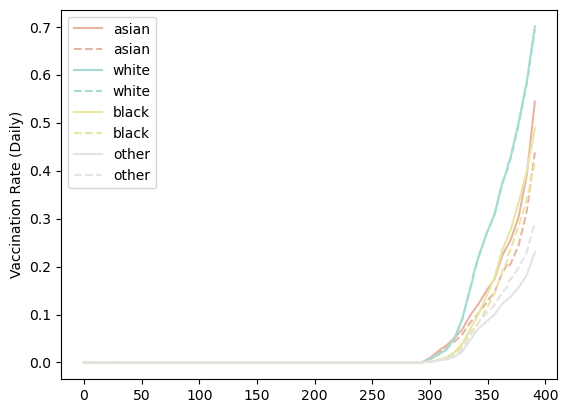

In [33]:
for r_idx in range(4):
    r = race_list_37[r_idx]
    plt.plot(M_eta[:,r_idx],label=r,color=custom_colors[r])
    plt.plot(M_eta_old[:,r_idx],'--',label=r,color=custom_colors[r])
plt.legend()
plt.ylabel('Vaccination Rate (Daily)')

In [34]:
np.savetxt('M_eta_37_v2.csv',M_eta)
# M_eta_old = np.loadtxt('M_eta_37.csv')